In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
gdf = gpd.read_file("ede_reports-2.geojson")
gdf.head()

,OBJECTID,ID,reporting_date,tick_bite_date,longitude,latitude,postal_code,Unknown_1,city,municipality,...,P_HH_M_K,GEM_HH_GR,P_WEST_AL,P_N_W_AL,P_MAROKKO,P_ANT_ARU,P_SURINAM,P_TURKIJE,P_OVER_NW,geometry
0,18,20,2006-04-09,2006-04-09,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
1,37,40,2006-04-23,2006-04-23,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
2,59,62,2006-05-04,2006-05-04,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
3,241,247,2006-06-03,2006-06-03,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
4,326,334,2006-06-06,2006-06-06,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)


In [3]:
import pandas as pd
import numpy as np

# Replace "None" strings and other non-numeric values with NaN
gdf["reporting_date"] = pd.to_datetime(gdf["reporting_date"])
gdf["year_of_birth_clean"] = pd.to_numeric(gdf["year_of_birth"], errors="coerce")

# If you need it as a datetime (e.g., 1980 → 1980-01-01)
gdf["date_of_birth"] = pd.to_datetime(gdf["year_of_birth_clean"], format="%Y", errors="coerce")

# (Optional) Calculate age at time of tick bite
gdf["tick_bite_date"] = pd.to_datetime(gdf["reporting_date"], errors="coerce")
gdf["age_at_bite"] = gdf["tick_bite_date"].dt.year - gdf["date_of_birth"].dt.year

In [4]:
def categorize_activity(activity):
    if activity is None:
        return "Other"
    
    a = activity.lower()
    
    if "wandelen" in a:
        return "Walking"
    elif "honduitlaten" in a or "hond uitlaten" in a:
        return "Walking"
    elif "tuinieren" in a:
        return "Gardening"
    elif "spelen" in a:
        return "Playing"
    elif "picknicken" in a or "picknick" in a:
        return "Playing"
    elif "groenbeheer" in a:
        return "Gardening"
    elif "weetniet" in a or "weet niet" in a:
        return "Other"
    elif "anders" in a:
        return "Other"
    else:
        return "Other"

gdf["activity_grouped"] = gdf["activity"].apply(categorize_activity)

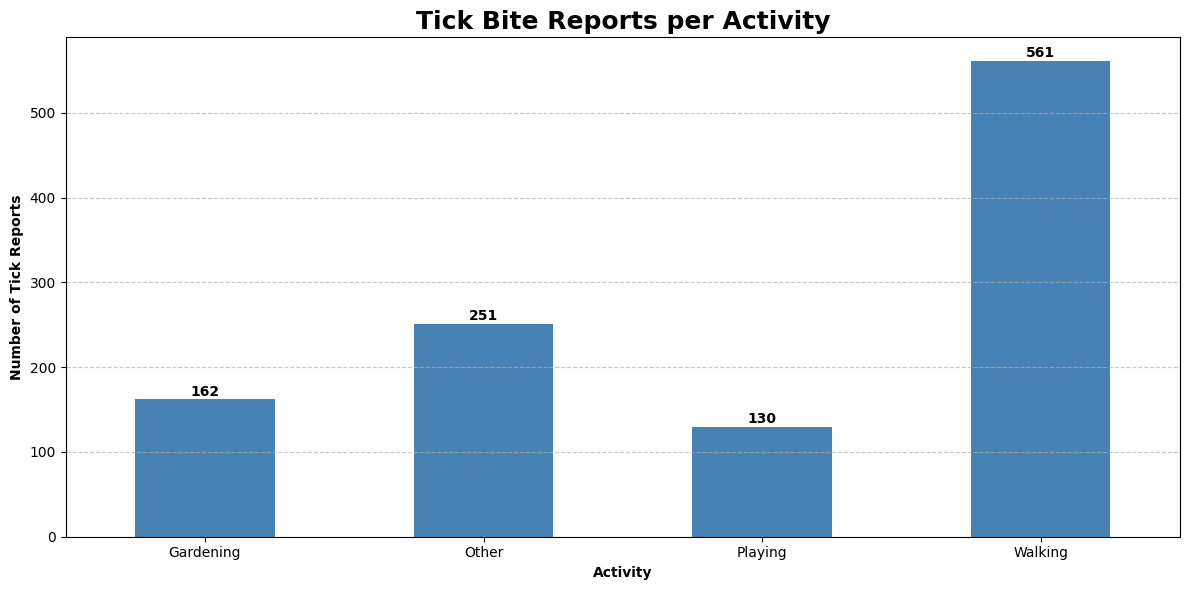

In [5]:
import matplotlib.pyplot as plt

# Group and count by activity
activity_count = gdf.groupby("activity_grouped").size().sort_index()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
activity_count.plot(kind='bar', ax=ax, color='steelblue')

# Titles and labels
ax.set_title("Tick Bite Reports per Activity", fontweight="bold", fontsize=18)
ax.set_xlabel("Activity", fontweight="bold")
ax.set_ylabel("Number of Tick Reports", fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of bars
for i, count in enumerate(activity_count):
    ax.text(i, count + 1, str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.savefig("total_ticks_reports_activitywise.png", dpi=300, bbox_inches='tight')
plt.show()


In [6]:
gdf.head()

,OBJECTID,ID,reporting_date,tick_bite_date,longitude,latitude,postal_code,Unknown_1,city,municipality,...,P_MAROKKO,P_ANT_ARU,P_SURINAM,P_TURKIJE,P_OVER_NW,geometry,year_of_birth_clean,date_of_birth,age_at_bite,activity_grouped
0,18,20,2006-04-09,2006-04-09,451000.0,173000.0,None,None,Ede,Ede,...,2,0,1,2,4,POINT (173000 451000),1968.0,1968-01-01,38.0,Walking
1,37,40,2006-04-23,2006-04-23,451000.0,173000.0,None,None,Ede,Ede,...,2,0,1,2,4,POINT (173000 451000),1967.0,1967-01-01,39.0,Walking
2,59,62,2006-05-04,2006-05-04,451000.0,173000.0,None,None,Ede,Ede,...,2,0,1,2,4,POINT (173000 451000),2000.0,2000-01-01,6.0,Other
3,241,247,2006-06-03,2006-06-03,451000.0,173000.0,None,None,Ede,Ede,...,2,0,1,2,4,POINT (173000 451000),1957.0,1957-01-01,49.0,Gardening
4,326,334,2006-06-06,2006-06-06,451000.0,173000.0,None,None,Ede,Ede,...,2,0,1,2,4,POINT (173000 451000),1986.0,1986-01-01,20.0,Playing


In [7]:
gdf_landuse = gpd.read_file("Landuse/Ede_lnduse.shp")
gdf_landuse.head()

,FID_BBG201,BG2015,BG2012,GM_CODE,GM_NAAM,WATER,OAD,STED,AANT_INW,AANT_MAN,...,P_OVER_NW,APR,MAY,JUN,JUL,AUG,SEP,OCT,WIN,geometry
0,12548,20,20,GM0228,Ede,NEE,1525,2,114682,56689,...,4,9,7,17,14,21,7,13,4,"MULTIPOLYGON (((174830.456 445373.371, 174846...."
1,129103,60,51,GM0228,Ede,NEE,1525,2,114682,56689,...,4,76,135,163,89,87,59,38,37,"MULTIPOLYGON (((178874.393 446364.874, 178874...."
2,154375,61,60,GM0228,Ede,NEE,1525,2,114682,56689,...,4,8,9,21,12,8,4,6,4,"MULTIPOLYGON (((176277.961 445527.091, 176278...."
3,163081,62,62,GM0228,Ede,NEE,1525,2,114682,56689,...,4,26,29,17,22,26,10,12,21,"MULTIPOLYGON (((174886.421 444791.894, 174868...."


In [8]:
gdf.crs

<Projected CRS: EPSG:28992>
Name: Amersfoort / RD New
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Netherlands - onshore, including Waddenzee, Dutch Wadden Islands and 12-mile offshore coastal zone.
- bounds: (3.2, 50.75, 7.22, 53.7)
Coordinate Operation:
- name: RD New
- method: Oblique Stereographic
Datum: Amersfoort
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [9]:
gdf_landuse.crs = "EPSG:28992"

In [10]:
if 'index_right' in gdf.columns:
    gdf = gdf.drop(columns='index_right')
if 'index_right' in gdf_landuse.columns:
    gdf_landuse = gdf_landuse.drop(columns='index_right')

In [11]:
gdf_landuse_combined = gpd.sjoin(gdf, gdf_landuse[["BG2015", "geometry"]], how="inner", predicate="within")

In [12]:
gdf_landuse_combined

,OBJECTID,ID,reporting_date,tick_bite_date,longitude,latitude,postal_code,Unknown_1,city,municipality,...,P_SURINAM,P_TURKIJE,P_OVER_NW,geometry,year_of_birth_clean,date_of_birth,age_at_bite,activity_grouped,index_right,BG2015
0,18,20,2006-04-09,2006-04-09,451000.000000,173000.000000,None,None,Ede,Ede,...,1,2,4,POINT (173000 451000),1968.0,1968-01-01,38.0,Walking,0,20
1,37,40,2006-04-23,2006-04-23,451000.000000,173000.000000,None,None,Ede,Ede,...,1,2,4,POINT (173000 451000),1967.0,1967-01-01,39.0,Walking,0,20
2,59,62,2006-05-04,2006-05-04,451000.000000,173000.000000,None,None,Ede,Ede,...,1,2,4,POINT (173000 451000),2000.0,2000-01-01,6.0,Other,0,20
3,241,247,2006-06-03,2006-06-03,451000.000000,173000.000000,None,None,Ede,Ede,...,1,2,4,POINT (173000 451000),1957.0,1957-01-01,49.0,Gardening,0,20
4,326,334,2006-06-06,2006-06-06,451000.000000,173000.000000,None,None,Ede,Ede,...,1,2,4,POINT (173000 451000),1986.0,1986-01-01,20.0,Playing,0,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,46702,48825,2016-10-28,2016-10-28,450872.135325,174414.136743,None,None,Goirle,Goirle,...,1,2,4,POINT (174414.137 450872.135),1979.0,1979-01-01,37.0,Walking,3,62
1100,46733,48858,2016-10-30,2016-10-30,452605.991241,181131.699656,6731SP,None,Otterlo,Ede,...,1,2,4,POINT (181131.7 452605.991),1953.0,1953-01-01,63.0,Other,1,60
1101,46758,48886,2016-11-01,2016-11-01,454375.846254,182822.059972,3512AN,None,Utrecht,Utrecht,...,1,2,4,POINT (182822.06 454375.846),1987.0,1987-01-01,29.0,Walking,1,60
1102,46809,48942,2016-11-08,2016-11-08,447675.327546,174802.352239,6721GG,None,Bennekom,Ede,...,1,2,4,POINT (174802.352 447675.328),1950.0,1950-01-01,66.0,Gardening,1,60


In [16]:
def age_group(age):
    if age < 20:
        return "Child"
    elif (age >=20) and (age < 60):
        return "Adult"
    else:
        return "Senior"
    
gdf_landuse_combined["agent-type"] = gdf_landuse_combined["age_at_bite"].apply(lambda x: age_group(x))

In [17]:
gdf_landuse_combined

,OBJECTID,ID,reporting_date,tick_bite_date,longitude,latitude,postal_code,Unknown_1,city,municipality,...,P_TURKIJE,P_OVER_NW,geometry,year_of_birth_clean,date_of_birth,age_at_bite,activity_grouped,index_right,BG2015,agent-type
0,18,20,2006-04-09,2006-04-09,451000.000000,173000.000000,None,None,Ede,Ede,...,2,4,POINT (173000 451000),1968.0,1968-01-01,38.0,Walking,0,20,Adult
1,37,40,2006-04-23,2006-04-23,451000.000000,173000.000000,None,None,Ede,Ede,...,2,4,POINT (173000 451000),1967.0,1967-01-01,39.0,Walking,0,20,Adult
2,59,62,2006-05-04,2006-05-04,451000.000000,173000.000000,None,None,Ede,Ede,...,2,4,POINT (173000 451000),2000.0,2000-01-01,6.0,Other,0,20,Child
3,241,247,2006-06-03,2006-06-03,451000.000000,173000.000000,None,None,Ede,Ede,...,2,4,POINT (173000 451000),1957.0,1957-01-01,49.0,Gardening,0,20,Adult
4,326,334,2006-06-06,2006-06-06,451000.000000,173000.000000,None,None,Ede,Ede,...,2,4,POINT (173000 451000),1986.0,1986-01-01,20.0,Playing,0,20,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,46702,48825,2016-10-28,2016-10-28,450872.135325,174414.136743,None,None,Goirle,Goirle,...,2,4,POINT (174414.137 450872.135),1979.0,1979-01-01,37.0,Walking,3,62,Adult
1100,46733,48858,2016-10-30,2016-10-30,452605.991241,181131.699656,6731SP,None,Otterlo,Ede,...,2,4,POINT (181131.7 452605.991),1953.0,1953-01-01,63.0,Other,1,60,Senior
1101,46758,48886,2016-11-01,2016-11-01,454375.846254,182822.059972,3512AN,None,Utrecht,Utrecht,...,2,4,POINT (182822.06 454375.846),1987.0,1987-01-01,29.0,Walking,1,60,Adult
1102,46809,48942,2016-11-08,2016-11-08,447675.327546,174802.352239,6721GG,None,Bennekom,Ede,...,2,4,POINT (174802.352 447675.328),1950.0,1950-01-01,66.0,Gardening,1,60,Senior


In [18]:
gdf_landuse_combined.columns

Index(['OBJECTID', 'ID', 'reporting_date', 'tick_bite_date', 'longitude',
       'latitude', 'postal_code', 'Unknown_1', 'city', 'municipality',
       'province', 'environment', 'activity', 'year_of_birth', 'zoom',
       'general_remarks', 'GM_CODE', 'GM_NAAM', 'WATER', 'OAD', 'STED',
       'AANT_INW', 'AANT_MAN', 'AANT_VROUW', 'P_00_14_JR', 'P_15_24_JR',
       'P_25_44_JR', 'P_45_64_JR', 'P_65_EO_JR', 'P_ONGEHUWD', 'P_GEHUWD',
       'P_GESCHEID', 'P_VERWEDUW', 'AANTAL_HH', 'P_EENP_HH', 'P_HH_Z_K',
       'P_HH_M_K', 'GEM_HH_GR', 'P_WEST_AL', 'P_N_W_AL', 'P_MAROKKO',
       'P_ANT_ARU', 'P_SURINAM', 'P_TURKIJE', 'P_OVER_NW', 'geometry',
       'year_of_birth_clean', 'date_of_birth', 'age_at_bite',
       'activity_grouped', 'index_right', 'BG2015', 'agent-type'],
      dtype='object')

In [19]:
columns = ["reporting_date", "latitude", "longitude", 'age_at_bite',
       'activity_grouped', 'BG2015', 'agent-type']

gdf_landuse_combined_1 = gdf_landuse_combined[columns]

In [21]:
gdf_landuse_combined_1.shape

(1104, 7)

In [23]:
gdf_landuse_combined_1.to_csv("ground-truth-tick-reports.csv", encoding="utf-8", index=False)